In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("./out_csv")
imu = pd.read_csv(base / "imu.csv")
imu2 = pd.read_csv(base / "imu2.csv")
imu_filter = pd.read_csv(base / "imu_filter.csv")
imu_soldada = pd.read_csv(base / "imu_com_filtro_soldada.csv")
imu_soldada2 = pd.read_csv(base / "imu_com_filtro_soldada_takeoff.csv")
imu_soldada3 = pd.read_csv(base / "imu_com_filtro_soldada_fit_takeoff.csv")
imu_soldada_completo = pd.read_csv(base / "imu_com_filtro_soldada_fita_completo.csv")
imu_soldada_8g = pd.read_csv(base / "imu_soldada_8g.csv")
imu_soldada_4g = pd.read_csv(base / "imu_soldada_4g.csv")
imu_soldada_2g = pd.read_csv(base / "imu_soldada_2g.csv")
imu_soldada_completo_8g = pd.read_csv(base / "imu_soldada_direta__8g.csv")
imu_soldada_completo_8g_parafuso = pd.read_csv(base / "imu_soldada_direta__8g_parafuso.csv")
imu_damper = pd.read_csv(base / "imu_8g_damper.csv")
imu_espuma = pd.read_csv(base / "imu_8g_espuma.csv")
imu_espuma2 = pd.read_csv(base / "imu_8g_espuma2.csv")
imu_espuma3 = pd.read_csv(base / "imu_8g_espuma3.csv")
imu_espuma4 = pd.read_csv(base / "imu_8g_espuma4.csv")
imu_espuma5 = pd.read_csv(base / "imu_8g_espuma5.csv")

imu_espuma6 = pd.read_csv(base / "imu_8g_espuma6.csv")
imu_espuma7 = pd.read_csv(base / "imu_8g_espuma7.csv")

two_imus = pd.read_csv(base / "2imu.csv")
two_imus2 = pd.read_csv(base / "2imu2.csv")
calibracao_2_imus = pd.read_csv(base / "calibracao.csv")
LOG_calibracao2 = pd.read_csv(base / "LOG_calibracao2.csv")
calibracao_2_imus_elips =  pd.read_csv(base / "calibracao_elips.csv")

motor_no_prop = pd.read_csv(base / "motor_no_prop.csv")

mao_2_imus = pd.read_csv(base / "mao_2_imus.csv")

pose = pd.read_csv(base / "bag" / "natnet_ros__B1__pose.csv")
takeoff = pd.read_csv(base / "bag" / "B1__takeoff.csv")
land = pd.read_csv(base / "bag" / "B1__land.csv")
odom = pd.read_csv(base / "bag" / "B1__odom.csv")
imu_mao_sem_filtro = pd.read_csv(base / "imu_na_mao_sem_filtro.csv")
imu_mao_com_filtro = pd.read_csv(base / "imu_mao_com_filtro.csv")

In [52]:
import numpy as np
import pandas as pd

def convert_imu_counts(
    df: pd.DataFrame,
    acc_range_g: int,
    gyro_range_dps: int,
    g0: float = 9.80665,
) -> pd.DataFrame:
    """
    Converte IMU counts (MPU) para unidades físicas.
    
    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo colunas ax*, ay*, az*, gx*, gy*, gz*
    acc_range_g : int
        Faixa do acelerômetro (2, 4, 8 ou 16)
    gyro_range_dps : int
        Faixa do giroscópio (250, 500, 1000 ou 2000)
    g0 : float
        Aceleração da gravidade (m/s²)

    Retorna
    -------
    df_out : pandas.DataFrame
        Novo DataFrame com colunas convertidas (m/s² e deg/s)
    """

    acc_lsb_per_g = {
        2: 16384.0,
        4: 8192.0,
        8: 4096.0,
        16: 2048.0,
    }

    gyro_lsb_per_dps = {
        250: 131.0,
        500: 65.5,
        1000: 32.8,
        2000: 16.4,
    }

    if acc_range_g not in acc_lsb_per_g:
        raise ValueError(f"Faixa de accel inválida: {acc_range_g} g")

    if gyro_range_dps not in gyro_lsb_per_dps:
        raise ValueError(f"Faixa de gyro inválida: {gyro_range_dps} dps")

    acc_scale = g0 / acc_lsb_per_g[acc_range_g]
    gyro_scale = 1.0 / gyro_lsb_per_dps[gyro_range_dps]

    df_out = df.copy()

    # --- ACC ---
    for col in df.columns:
        if col.startswith(("ax", "ay", "az")):
            df_out[col + "_ms2"] = df[col] * acc_scale

    # --- GYRO ---
    for col in df.columns:
        if col.startswith(("gx", "gy", "gz")):
            df_out[col + "_dps"] = df[col] * gyro_scale

    return df_out

In [53]:
two_imus_n = convert_imu_counts(
    two_imus2,
    acc_range_g=8,       # ±8 g
    gyro_range_dps=500   # ±500 dps
)

In [54]:
two_imus_n.head()

,t_us,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,...,az1_ms2,ax2_ms2,ay2_ms2,az2_ms2,gx1_dps,gy1_dps,gz1_dps,gx2_dps,gy2_dps,gz2_dps
0,1934273,238.0,279.0,3891.0,32.0,-4.0,4.0,306.0,80.0,3930.0,...,9.315839,0.732626,0.191536,9.409213,0.488550,-0.061069,0.061069,-0.671756,-1.664122,-1.068702
1,1935273,235.0,282.0,3882.0,34.0,-7.0,0.0,310.0,81.0,3928.0,...,9.294291,0.742203,0.193930,9.404424,0.519084,-0.106870,0.000000,-0.763359,-1.709924,-1.022901
2,1936273,241.0,282.0,3874.0,35.0,-7.0,-4.0,311.0,88.0,3919.0,...,9.275137,0.744597,0.210690,9.382876,0.534351,-0.106870,-0.061069,-0.809160,-1.770992,-1.007634
3,1937273,244.0,281.0,3866.0,34.0,-7.0,-2.0,311.0,91.0,3910.0,...,9.255984,0.744597,0.217872,9.361328,0.519084,-0.106870,-0.030534,-0.793893,-1.816794,-1.038168
4,1938273,241.0,281.0,3868.0,32.0,-6.0,3.0,318.0,90.0,3906.0,...,9.260772,0.761356,0.215478,9.351752,0.488550,-0.091603,0.045802,-0.671756,-1.755725,-1.007634


In [55]:
t = (two_imus_n["t_us"] - two_imus_n["t_us"][0])/1000000
t

0         0.000000
1         0.001000
2         0.002000
3         0.003000
4         0.004000
           ...    
43003    43.107653
43004    43.108653
43005    43.109653
43006    43.110653
43007    43.111653
Name: t_us, Length: 43008, dtype: float64

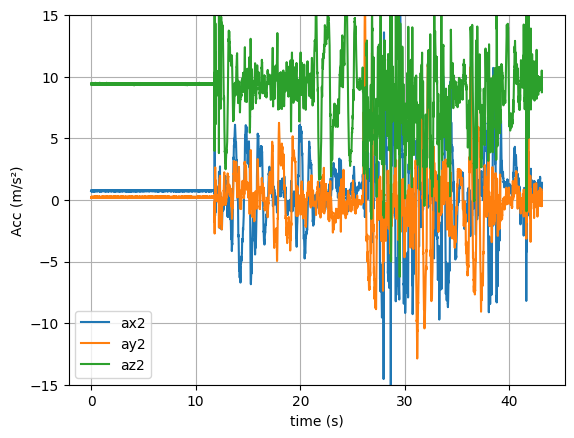

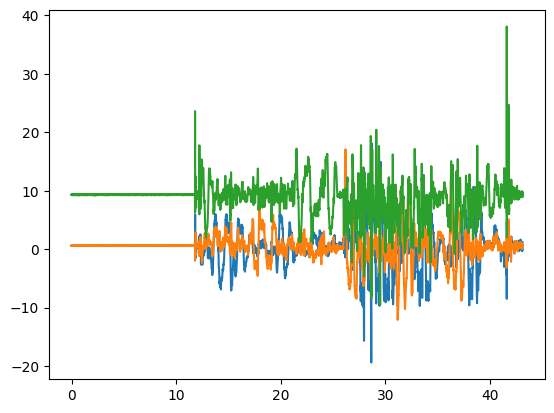

In [56]:
# Labels
get_all =True
limits = [100, 120]
new_two_imus = two_imus_n
t_plot = t

if not get_all:
    min_idx = (t - limits[0]).abs().idxmin()
    max_idx = (t - limits[1]).abs().idxmin()

    new_two_imus = new_two_imus.iloc[min_idx:max_idx]
    t_plot = t_plot[min_idx:max_idx]

plt.figure()

plt.plot(t_plot, new_two_imus["ax2_ms2"], label="ax2")
plt.plot(t_plot, new_two_imus["ay2_ms2"], label="ay2")
plt.plot(t_plot, new_two_imus["az2_ms2"], label="az2")

plt.ylim([-15, 15])
plt.xlabel("time (s)")
plt.ylabel("Acc (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(t_plot, new_two_imus["ax1_ms2"])
plt.plot(t_plot, new_two_imus["ay1_ms2"])
plt.plot(t_plot, new_two_imus["az1_ms2"])

#plt.ylabel("Acc (m/s^2)")
#plt.xlabel("time (s)")

(0.0, 7300.0)

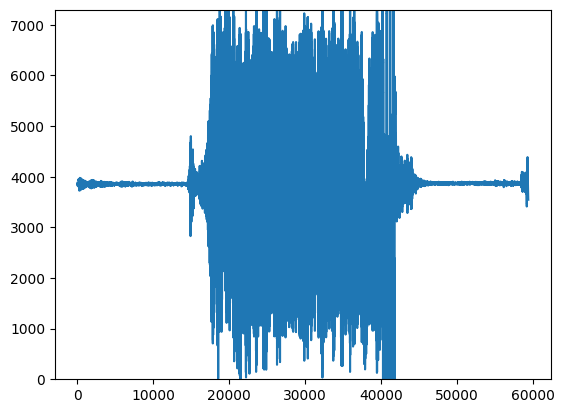

In [57]:
plt.plot(imu_espuma7["az"], label="ax2")
plt.ylim([0, 7300])

In [58]:
# x -> de -4000 para 1000 de amplitude
# y -> de -2000 para 1000 de amplitude
# z -> de  2800 para 7000 de amplitude

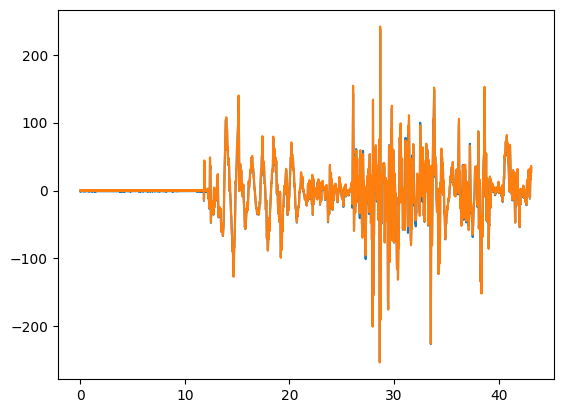

In [59]:
plt.plot(t_plot, new_two_imus["gz2_dps"])
plt.plot(t_plot, new_two_imus["gz1_dps"])

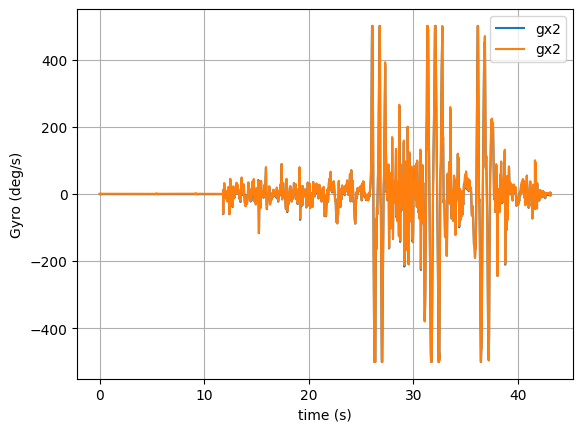

In [60]:
plt.figure()

plt.plot(t_plot, new_two_imus["gx2_dps"], label="gx2")
plt.plot(t_plot, new_two_imus["gx1_dps"], label="gx2")

#plt.plot(t_plot, new_two_imus["gy2_dps"], label="gy2")
#plt.plot(t_plot, new_two_imus["gz2_dps"], label="gz2")

#plt.ylim([-15, 15])
plt.xlabel("time (s)")
plt.ylabel("Gyro (deg/s)")
plt.legend()
plt.grid(True)
plt.show()

# Parte de Calibração

In [61]:
faces_t = {
    "+z": ( 20,  27),
    "-z": ( 37,  47),
    "+x": ( 85,  97),
    "-x": ( 52,  60),
    "+y": ( 67,  77),
    "-y": ( 104, 116),
}

=== Face medians (IMU2) ===
     ax2_ms2   ay2_ms2   az2_ms2      norm
+z  0.788889 -0.217872  9.236830  9.273017
-z  0.849942  0.009577  9.153033  9.192416
+x       NaN       NaN       NaN       NaN
-x       NaN       NaN       NaN       NaN
+y       NaN       NaN       NaN       NaN
-y       NaN       NaN       NaN       NaN

=== Bias (m/s^2) ===
{'x': np.float64(nan), 'y': np.float64(nan), 'z': np.float64(9.194931475830078)}

=== Scale gain k (multiply) ===
{'x': np.float64(nan), 'y': np.float64(nan), 'z': np.float64(234.0571428571409)}

=== Validation per face (median of calibrated) ===
+z  vec={'ax2_cal': nan, 'ay2_cal': nan, 'az2_cal': 9.806649999999792}  norm=nan (target 9.8066)
-z  vec={'ax2_cal': nan, 'ay2_cal': nan, 'az2_cal': -9.806650000000207}  norm=nan (target 9.8066)
+x  vec={'ax2_cal': nan, 'ay2_cal': nan, 'az2_cal': nan}  norm=nan (target 9.8066)
-x  vec={'ax2_cal': nan, 'ay2_cal': nan, 'az2_cal': nan}  norm=nan (target 9.8066)
+y  vec={'ax2_cal': nan, 'ay2_cal': nan, 

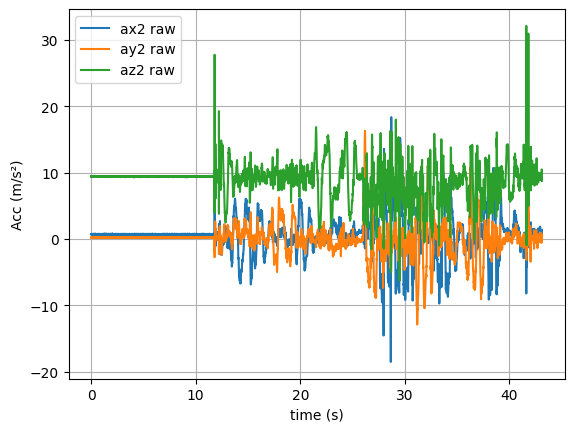

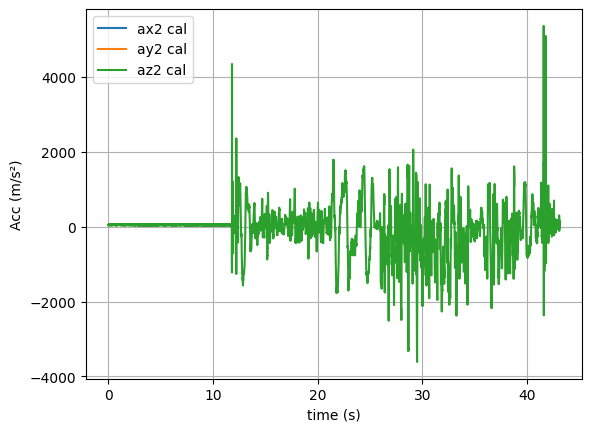

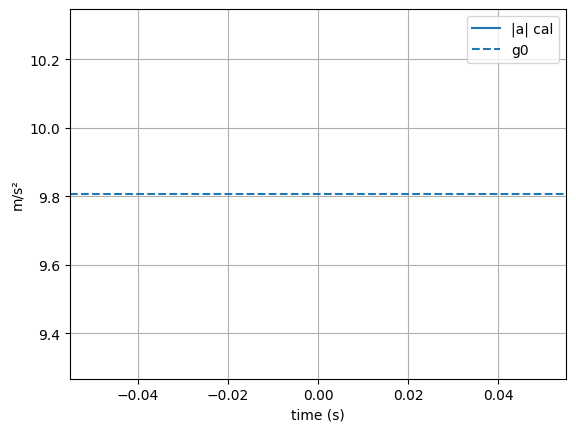

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g0 = 9.80665
cols = ["ax2_ms2", "ay2_ms2", "az2_ms2"]

faces_t = {
    "+z": (  20,  27),
    "-z": (  37,  47),
    "+x": (  85,  97),
    "-x": (  52,  60),
    "+y": (  67,  77),
    "-y": ( 104, 116),
}

# --- helpers ---
t_arr = np.asarray(t_plot).ravel()

def t_to_idx(t, t0, t1):
    idx0 = (t - t0).abs().idxmin()
    idx1 = (t - t1).abs().idxmin()

    return idx0, idx1

def face_vector(df, i0, i1):
    # mediana = mais robusta se você mexeu um pouco
    return df.iloc[i0:i1][cols].median()

# --- 1) extrai vetor representativo de cada face ---
face_vec = {}
face_idx = {}

for face, (t0, t1) in faces_t.items():
    i0, i1 = t_to_idx(t, t0, t1)
    face_idx[face] = (i0, i1)
    face_vec[face] = face_vector(new_two_imus, i0, i1)

face_df = pd.DataFrame(face_vec).T
face_df["norm"] = np.linalg.norm(face_df[cols].to_numpy(), axis=1)

print("=== Face medians (IMU2) ===")
print(face_df[[*cols, "norm"]])

# --- 2) calcula bias e ganho por eixo (modelo diagonal) ---
b = {}
k = {}

# eixo x usa +x e -x, etc.
for axis, col in zip(["x","y","z"], cols):
    a_plus  = face_vec[f"+{axis}"][col]
    a_minus = face_vec[f"-{axis}"][col]

    b[axis] = 0.5 * (a_plus + a_minus)
    denom   = 0.5 * (a_plus - a_minus)           # deveria ser ~ +g0 (com sinal)
    k[axis] = g0 / denom

print("\n=== Bias (m/s^2) ===")
print(b)
print("\n=== Scale gain k (multiply) ===")
print(k)

# se algum ganho sair negativo, significa que seu eixo está invertido (ou a face foi trocada)
neg = [ax for ax in k if k[ax] < 0]
if neg:
    print("\n[AVISO] Ganho negativo em:", neg,
          "\nIsso indica eixo invertido ou alguma face +/− trocada. A calibração ainda pode ser usada, mas revise.")

# --- 3) aplica correção ao sinal inteiro ---
cal = new_two_imus.copy()

cal["ax2_cal"] = (cal["ax2_ms2"] - b["x"]) * k["x"]
cal["ay2_cal"] = (cal["ay2_ms2"] - b["y"]) * k["y"]
cal["az2_cal"] = (cal["az2_ms2"] - b["z"]) * k["z"]

cal["acc2_norm_cal"] = np.sqrt(cal["ax2_cal"]**2 + cal["ay2_cal"]**2 + cal["az2_cal"]**2)

# --- 4) valida por face ---
print("\n=== Validation per face (median of calibrated) ===")
for face, (i0, i1) in face_idx.items():
    v = cal.iloc[i0:i1][["ax2_cal","ay2_cal","az2_cal"]].median()
    n = float(np.linalg.norm(v.to_numpy()))
    print(f"{face:>2}  vec={v.to_dict()}  norm={n:.4f} (target {g0:.4f})")

# --- 5) plot comparando antes/depois (opcional) ---
plt.figure()
plt.plot(t_arr, new_two_imus["ax2_ms2"], label="ax2 raw")
plt.plot(t_arr, new_two_imus["ay2_ms2"], label="ay2 raw")
plt.plot(t_arr, new_two_imus["az2_ms2"], label="az2 raw")
plt.xlabel("time (s)")
plt.ylabel("Acc (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_arr, cal["ax2_cal"], label="ax2 cal")
plt.plot(t_arr, cal["ay2_cal"], label="ay2 cal")
plt.plot(t_arr, cal["az2_cal"], label="az2 cal")
plt.xlabel("time (s)")
plt.ylabel("Acc (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_arr, cal["acc2_norm_cal"], label="|a| cal")
plt.axhline(g0, linestyle="--", label="g0")
plt.xlabel("time (s)")
plt.ylabel("m/s²")
plt.legend()
plt.grid(True)
plt.show()


In [63]:
# Filter acc
seconds = 10

time_idx = (t - seconds).abs().idxmin()

m_acc_x1 = np.mean(new_two_imus["ax1_ms2"].iloc[:time_idx])
m_acc_x2 = np.mean(new_two_imus["ax2_ms2"].iloc[:time_idx])

accx1_fixed = np.array(new_two_imus["ax1_ms2"] - m_acc_x1)
accx2_fixed = np.array(new_two_imus["ax2_ms2"] - m_acc_x2)

m_acc_y1 = np.mean(new_two_imus["ay1_ms2"].iloc[:time_idx])
m_acc_y2 = np.mean(new_two_imus["ay2_ms2"].iloc[:time_idx])

accy1_fixed = np.array(new_two_imus["ay1_ms2"] - m_acc_y1)
accy2_fixed = np.array(new_two_imus["ay2_ms2"] - m_acc_y2)

m_acc_z1 = np.mean(new_two_imus["az1_ms2"].iloc[:time_idx])
m_acc_z2 = np.mean(new_two_imus["az2_ms2"].iloc[:time_idx])

accz1_fixed = np.array(new_two_imus["az1_ms2"] - m_acc_z1)
accz2_fixed = np.array(new_two_imus["az2_ms2"] - m_acc_z2)

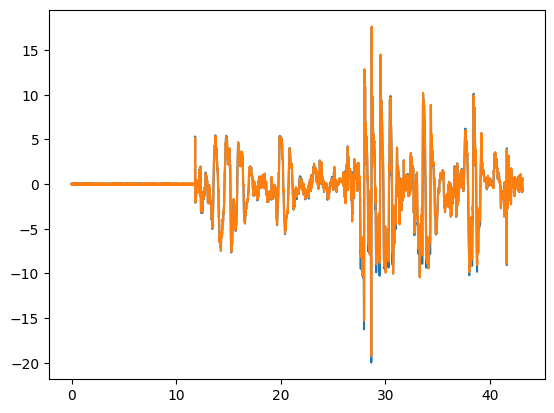

In [64]:
plt.plot(t, accx1_fixed)
plt.plot(t, accx2_fixed)

Text(0.5, 0, 'time (s)')

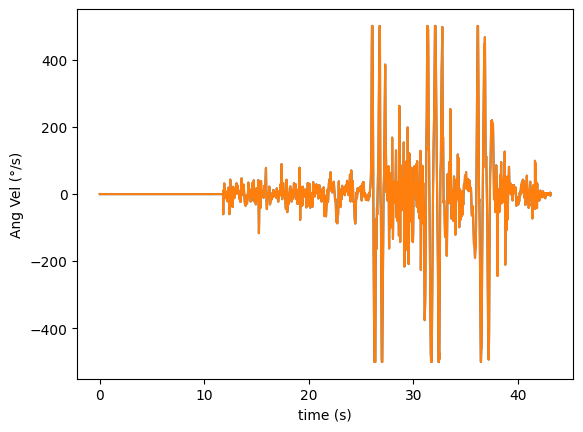

In [65]:
plt.plot(t, two_imus_n["gx2_dps"])
plt.plot(t, two_imus_n["gx2_dps"])

plt.ylabel("Ang Vel (°/s)")
plt.xlabel("time (s)")

In [66]:
# -------------------------
# 1) Tempo do SD (arbitrário) -> segundos relativos
# -------------------------
imu = imu.sort_values("t_us").reset_index(drop=True)
imu["t_sd"] = (imu["t_us"] - imu["t_us"].iloc[0]) * 1e-6

# métrica "energia" raw pra detectar eventos (não precisa calibrar)
imu["acc_norm"] = np.sqrt(imu["ax"]**2 + imu["ay"]**2 + imu["az"]**2)
imu["gyro_norm"] = np.sqrt(imu["gx"]**2 + imu["gy"]**2 + imu["gz"]**2)

In [67]:
# print all data in the range 964400 to 964475 without truncating the exit
pd.set_option('display.max_rows', None)
print(imu.iloc[964400:964475].loc[:, ["t_sd", "ax"]])
pd.reset_option('display.max_rows')

              t_sd       ax
964400  400.562054 -24935.0
964401  400.562457 -22919.0
964402  400.562861 -32363.0
964403  400.563264 -11454.0
964404  400.563668 -10192.0
964405  400.564071   9401.0
964406  400.564475  16782.0
964407  400.564878  25931.0
964408  400.565282  32767.0
964409  400.565685  28152.0
964410  400.566089  14863.0
964411  400.566493   3446.0
964412  400.566896  -1978.0
964413  400.567300 -25817.0
964414  400.567703 -27380.0
964415  400.568107 -29760.0
964416  400.568510 -32768.0
964417  400.568914 -12532.0
964418  400.569317  -5629.0
964419  400.569721   6712.0
964420  400.570124  22828.0
964421  400.570528  27330.0
964422  400.570931  32767.0
964423  400.571335  23047.0
964424  400.571738  19413.0
964425  400.572142   -462.0
964426  400.572545   -441.0
964427  400.572949 -22968.0
964428  400.573352 -24105.0
964429  400.573756 -26727.0
964430  400.574159 -28491.0
964431  400.574563 -14807.0
964432  400.574966  -9818.0
964433  400.575370  15313.0
964434  400.575773  

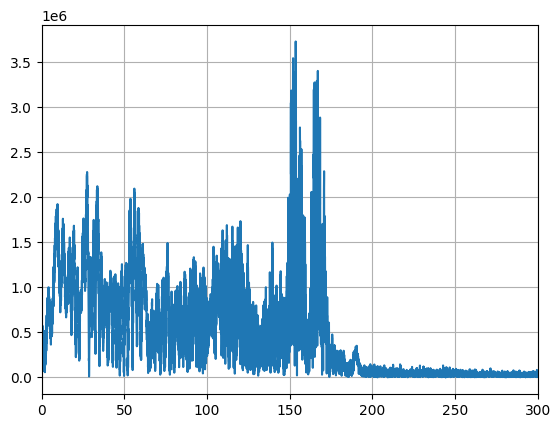

In [68]:
df = imu_espuma

t = df['t_s'].values
x = df['ax'].values

from scipy.interpolate import interp1d

fs_target = 2500  # Hz fixo
t_uniform = np.arange(t[0], t[-1], 1/fs_target)

interp = interp1d(t, x, kind='linear', fill_value="extrapolate")
x_uniform = interp(t_uniform)

X = np.fft.fft(x_uniform - np.mean(x_uniform))
freqs = np.fft.fftfreq(len(X), d=1/fs_target)

idx = freqs >= 0
plt.plot(freqs[idx], np.abs(X[idx]))
plt.grid()
plt.xlim((0, 300))
plt.show()

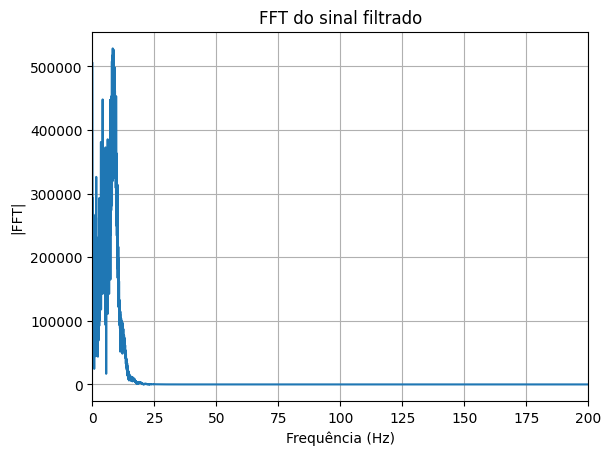

In [69]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

fs = fs_target  # o que você usou na reamostragem
fc = 10         # Hz

b, a = butter(4, fc/(fs/2), btype='low')
x_filt = filtfilt(b, a, x_uniform)

fs = fs_target  # Hz

# remover DC + janela (importante!)
x = x_filt - np.mean(x_filt)
x = x * windows.hann(len(x))

# FFT
X = np.fft.fft(x)
freqs = np.fft.fftfreq(len(X), d=1/fs)

# só parte positiva
idx = freqs >= 0

plt.plot(freqs[idx], np.abs(X[idx]))
plt.xlabel("Frequência (Hz)")
plt.ylabel("|FFT|")
plt.title("FFT do sinal filtrado")
plt.xlim((0, 200))
plt.grid(True)
plt.show()



(-3000.0, 3000.0)

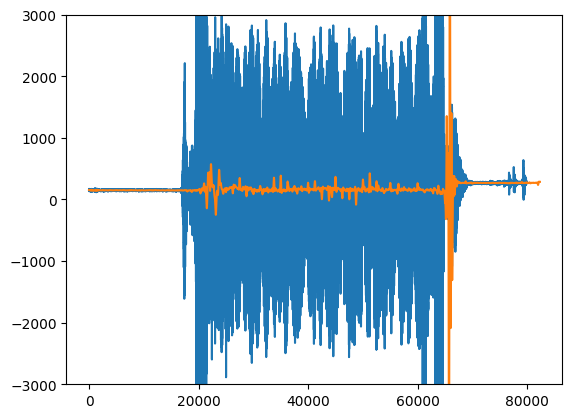

In [70]:
x = df['ax'].values
plt.plot(x)
plt.plot(x_filt)
plt.ylim((-3000, 3000))

(-300.0, 500.0)

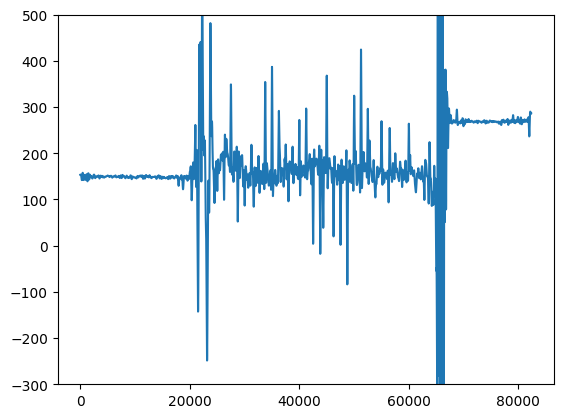

In [71]:
plt.plot(x_filt)
plt.ylim((-300, 500))

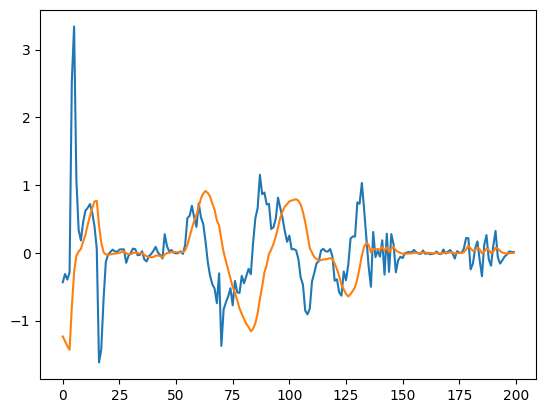

In [72]:
#derivada da velocidade
dt = np.diff(odom["t_msg"].values)
ax_odom = np.concatenate(([0], np.diff(odom["vx"].values) / dt ))

# Odom vx em numpy
odom_np = odom["vx"].values

plt.plot(ax_odom[200:400])
plt.plot(odom_np[200:400])

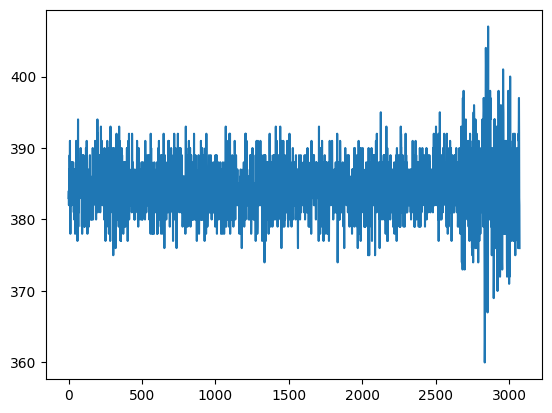

In [73]:
plt.plot(imu_filter["ax"])

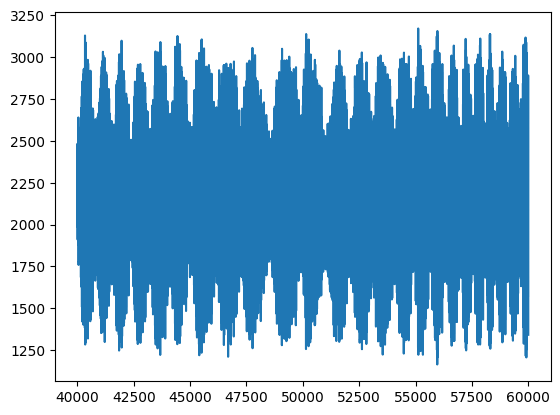

In [74]:
plt.plot(imu_soldada3["az"].iloc[40000:60000])

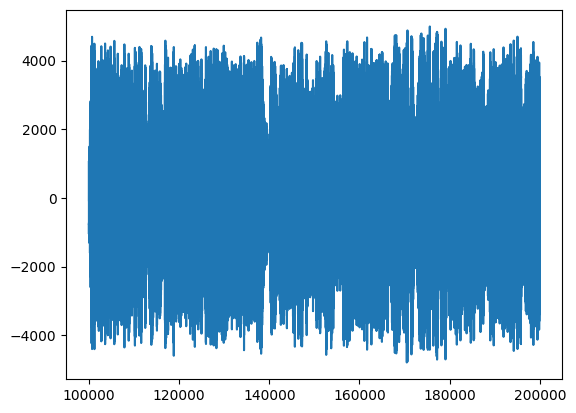

In [75]:
plt.plot(imu_soldada_completo["ax"].iloc[100000:200000])

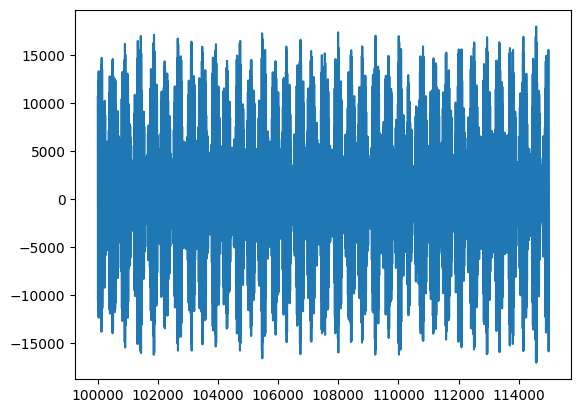

In [76]:
plt.plot(imu_soldada_4g["ax"].iloc[100000:115000])

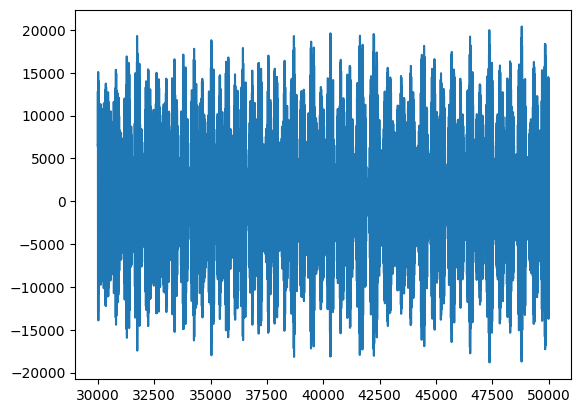

In [77]:
plt.plot(imu_soldada_2g["ay"].iloc[30000:50000])

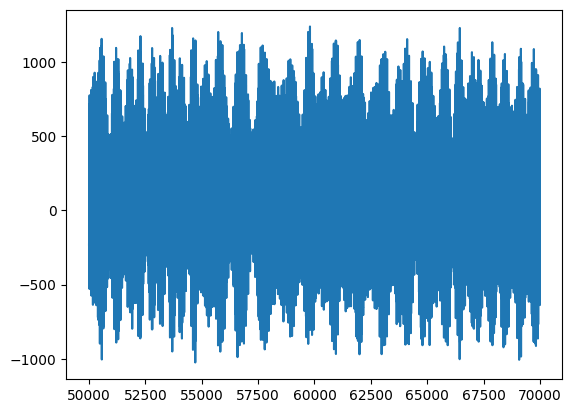

In [78]:
plt.plot(imu_soldada_8g["gz"].iloc[50000:70000])

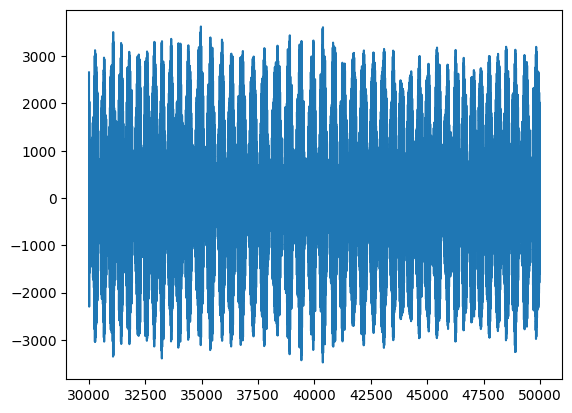

In [79]:
plt.plot(imu_soldada_completo_8g["gx"].iloc[30000:50000])

In [80]:
import numpy as np

# -----------------------------
# 2nd-order low-pass biquad (Butterworth, Q = 1/sqrt(2))
# Cookbook formula (RBJ)
# -----------------------------
def biquad_lowpass_coeff(fs_hz: float, fc_hz: float, q: float = 1/np.sqrt(2)):
    if fc_hz <= 0 or fc_hz >= fs_hz / 2:
        raise ValueError("fc_hz must be between (0, fs/2).")
    w0 = 2.0 * np.pi * (fc_hz / fs_hz)
    cosw0 = np.cos(w0)
    sinw0 = np.sin(w0)
    alpha = sinw0 / (2.0 * q)

    b0 = (1 - cosw0) / 2
    b1 = (1 - cosw0)
    b2 = (1 - cosw0) / 2
    a0 = 1 + alpha
    a1 = -2 * cosw0
    a2 = 1 - alpha

    # normalize so a0 = 1
    b = np.array([b0, b1, b2], dtype=np.float64) / a0
    a = np.array([1.0, a1 / a0, a2 / a0], dtype=np.float64)
    return b, a

def biquad_filter(x: np.ndarray, b: np.ndarray, a: np.ndarray):
    """
    Direct Form I biquad filtering.
    a[0] must be 1.0
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.zeros_like(x)

    # state
    x1 = x2 = 0.0
    y1 = y2 = 0.0

    b0, b1, b2 = b
    _, a1, a2 = a

    for n in range(x.size):
        xn = x[n]
        yn = b0*xn + b1*x1 + b2*x2 - a1*y1 - a2*y2
        y[n] = yn

        x2, x1 = x1, xn
        y2, y1 = y1, yn

    return y

def filter_then_downsample(
    x: np.ndarray,
    fs_in: float = 4000.0,
    fs_out: float = 200.0,
    fc_hz: float = 40.0
):
    """
    1) low-pass filter at fc_hz
    2) downsample to fs_out using block-mean (anti-alias already done by LPF)

    Returns: (y_ds, fs_out)
    """
    if fs_out <= 0 or fs_out > fs_in:
        raise ValueError("fs_out must be in (0, fs_in].")

    # design LPF
    b, a = biquad_lowpass_coeff(fs_in, fc_hz)

    # filter
    y = biquad_filter(x, b, a)

    # downsample ratio (must be integer for simple block mean)
    r = int(round(fs_in / fs_out))
    if abs(fs_in / fs_out - r) > 1e-6:
        raise ValueError(f"fs_in/fs_out must be integer for this simple downsampler. Got {fs_in/fs_out:.6f}")

    n = (y.size // r) * r
    y = y[:n]

    # block-mean (acts like a tiny extra LPF)
    y_ds = y.reshape(-1, r).mean(axis=1)

    return y_ds, fs_out

# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Suppose you have raw accel X in counts at 4 kHz:
    ax_counts = np.array(imu_soldada_completo["ax"])
    ay_counts = np.array(imu_soldada_completo["ay"])
    az_counts = np.array(imu_soldada_completo["az"])

    # Pick params:
    fs_in = 4000.0
    fs_out = 200.0
    fc = 40.0  # try 30, 40, 50

    ax_filt_ds, _ = filter_then_downsample(ax_counts, fs_in, fs_out, fc)
    ay_filt_ds, _ = filter_then_downsample(ay_counts, fs_in, fs_out, fc)
    az_filt_ds, _ = filter_then_downsample(az_counts, fs_in, fs_out, fc)
    print(ax_filt_ds[:10])
    pass


[ 20.29127133  82.60033658 120.67779952 128.76718029 125.87756107
 123.82425082 122.7170643  121.20048299 118.58569442 119.03660808]


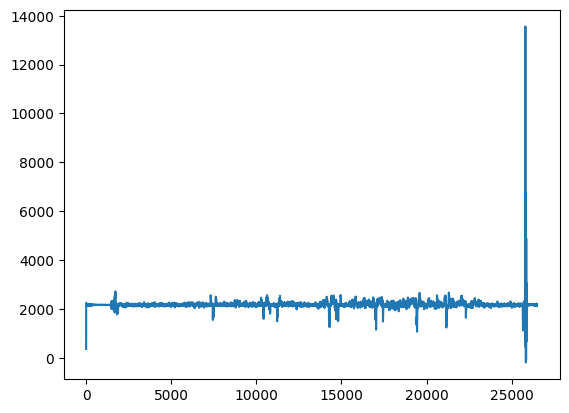

In [81]:
plt.plot(az_filt_ds)

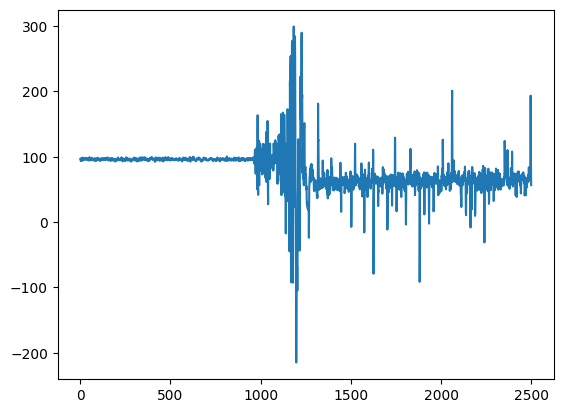

In [82]:
plt.plot(ay_filt_ds[500:3000])

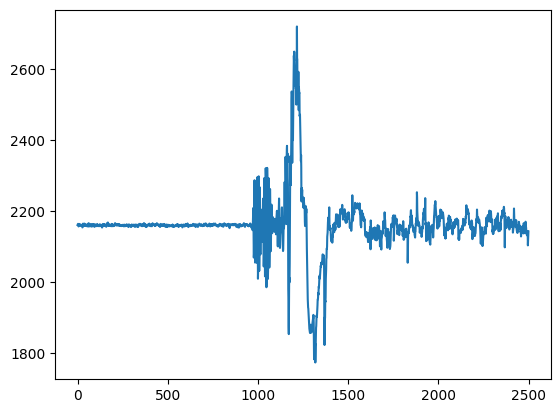

In [83]:
plt.plot(az_filt_ds[500:3000])

In [84]:
np.max(imu_mao_sem_filtro["ax"])

np.float64(12694.0)

In [85]:
32768

32768

# 16g

In [86]:
inteiro = 4500
acc = inteiro * 16/32768 * 9.81
f_g = inteiro * 16/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 21.55517578125
Aceleração em g: 2.197265625


# 8g

In [87]:
inteiro = 10000
acc = inteiro * 8/32768 * 9.81
f_g = inteiro * 8/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 23.9501953125
Aceleração em g: 2.44140625


# 4g

In [88]:
inteiro = 1000
acc = inteiro * 4/32768 * 9.81
f_g = inteiro * 4/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 1.197509765625
Aceleração em g: 0.1220703125


# 2g

In [89]:
inteiro = 30000
acc = inteiro * 2/32768 * 9.81
f_g = inteiro * 2/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 17.962646484375
Aceleração em g: 1.8310546875


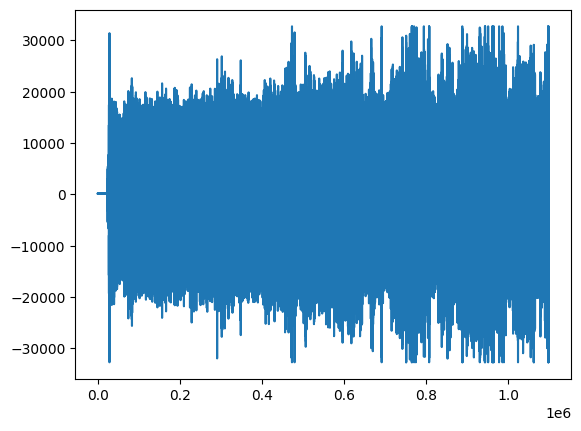

In [90]:
plt.plot(imu["ax"])



In [91]:
imu = imu_espuma7

In [92]:
# Calcula Angulos Absolutos
# AngsRoll = atan2(imu["ay"])
dataset = imu_espuma7
accX = dataset["ax"]/32768 * 9.8
accY = dataset["ay"]/32768 * 9.8
accZ = dataset["az"]/32768 * 9.8
AngsRoll = np.atan(accY/(np.sqrt(accX*accX + accZ*accZ)))*1/(3.142/180)
AngsPitch = np.atan(accX/np.sqrt(accY*accY + accZ*accZ))*1/(3.142/180)


0         1.339057
1         1.339057
2         1.339057
3         1.430361
4         1.430361
           ...    
59387    12.611223
59388    12.611223
59389    12.908991
59390    12.908991
59391    12.908991
Length: 59392, dtype: float64


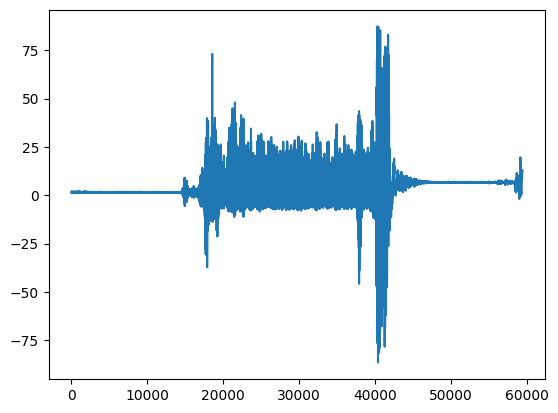

In [93]:
print(AngsRoll)
plt.plot(AngsRoll)

# Ruido sem os motores
# plt.plot(AngsRoll[0:20000])


0       -4.772717
1       -4.772717
2       -4.772717
3       -4.723578
4       -4.723578
           ...   
59387    0.850811
59388    0.850811
59389    1.117908
59390    1.117908
59391    1.117908
Length: 59392, dtype: float64


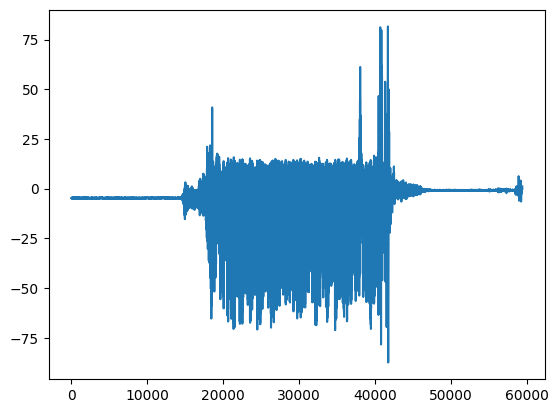

In [94]:
print(AngsPitch)
plt.plot(AngsPitch)

# Ruido sem os motores
# plt.plot(AngsPitch[0:20000])

In [95]:
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch

def lowpass_zero_phase(x, fs, fc=30.0, order=4):
    """
    x: array 1D (ex: ax, ay, az)
    fs: sample rate (Hz)
    fc: cutoff (Hz) - ex: 20~50Hz pra tirar vibração de motor
    """
    x = np.asarray(x, dtype=float)
    wn = fc / (fs * 0.5)
    b, a = butter(order, wn, btype="low")
    return filtfilt(b, a, x)

def notch_zero_phase(x, fs, f0, Q=30):
    """
    f0: frequência a remover (Hz)
    Q: qualidade (quanto maior, mais estreito)
    """
    x = np.asarray(x, dtype=float)
    w0 = f0 / (fs * 0.5)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, x)


In [96]:
ax = imu["ax"].to_numpy()
ay = imu["ay"].to_numpy()
az = imu["az"].to_numpy()

fs = 2400.0  # sua taxa
ax_f = lowpass_zero_phase(ax, fs, fc=30)
ay_f = lowpass_zero_phase(ay, fs, fc=30)
az_f = lowpass_zero_phase(az, fs, fc=30)

In [97]:
ax2 = notch_zero_phase(ax, fs, f0=220, Q=35)
ax2 = lowpass_zero_phase(ax2, fs, fc=3, order=4)

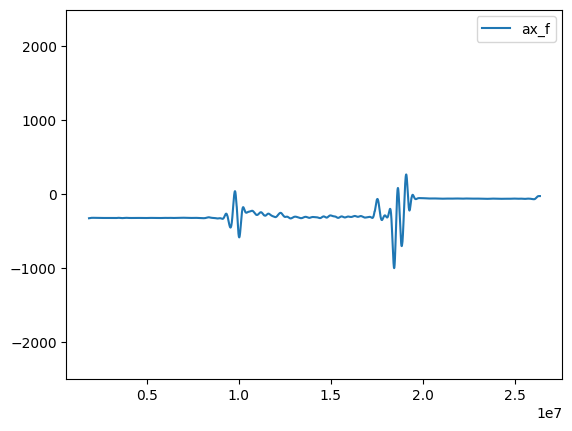

In [98]:
plt.plot(imu["t_us"], ax2, label="ax_f")
#plt.plot(imu["t_sd"], ay_f, label="ay_f")
#plt.plot(imu["t_sd"], az_f, label="az_f")
plt.ylim(-2500, 2500)
plt.legend()


In [99]:
# -------------------------
# 2) Converter takeoff/land (t_bag) -> tempo do OptiTrack (t_msg)
# usando offset robusto median(t_msg - t_bag)
# -------------------------
pose = pose.sort_values("t_msg").reset_index(drop=True)

# offset constante (aprox) entre stamp e bag time
dt_msg_bag = (pose["t_msg"] - pose["t_bag"]).median()

t_takeoff_msg = float(takeoff["t_bag"].iloc[0] + dt_msg_bag)
t_land_msg = float(land["t_bag"].iloc[-1] + dt_msg_bag)

print("takeoff_msg_est =", t_takeoff_msg)
print("land_msg_est   =", t_land_msg)

takeoff_msg_est = 1766072240.9300103
land_msg_est   = 1766072688.4266806


In [100]:

# -------------------------
# 3) Detectar takeoff no OptiTrack pelo movimento em Z
# -------------------------
# pega janela ao redor do takeoff estimado (ex. +/- 3s)
w0, w1 = t_takeoff_msg - 3.0, t_takeoff_msg + 6.0
pw = pose[(pose["t_msg"] >= w0) & (pose["t_msg"] <= w1)].copy()
pw = pw.sort_values("t_msg")

# derivadas simples
pw["dt"] = pw["t_msg"].diff()
pw["vz"] = pw["pz"].diff() / pw["dt"]
pw["az_est"] = pw["vz"].diff() / pw["dt"]

# takeoff = primeiro instante onde vz passa um limiar
# (ajusta se necessário)
vz_thr = 0.2  # m/s (chute bom)
idx_to = pw.index[(pw["vz"] > vz_thr) & (pw["dt"] > 0)].min()
t_takeoff_opt = float(pw.loc[idx_to, "t_msg"]) if pd.notna(idx_to) else t_takeoff_msg
print("takeoff_optitrack_detect =", t_takeoff_opt)

# detectar land similar (queda em vz negativa)
w0, w1 = t_land_msg - 6.0, t_land_msg + 3.0
pwL = pose[(pose["t_msg"] >= w0) & (pose["t_msg"] <= w1)].copy().sort_values("t_msg")
pwL["dt"] = pwL["t_msg"].diff()
pwL["vz"] = pwL["pz"].diff() / pwL["dt"]
vz_thr_down = -0.2
idx_land = pwL.index[(pwL["vz"] < vz_thr_down) & (pwL["dt"] > 0)].min()
t_land_opt = float(pwL.loc[idx_land, "t_msg"]) if pd.notna(idx_land) else t_land_msg
print("land_optitrack_detect =", t_land_opt)

takeoff_optitrack_detect = 1766072243.075623
land_optitrack_detect = 1766072686.7728183


In [101]:
# -------------------------
# 4) Detectar takeoff no SD IMU usando mudança de "energia" (acc_norm ou gyro_norm)
# -------------------------
# cria baseline em uma janela inicial (primeiros 2s)
base_mask = imu["t_sd"] < 2.0
mu = imu.loc[base_mask, "gyro_norm"].median()
mad = (imu.loc[base_mask, "gyro_norm"] - mu).abs().median()   # MAD robusto
sigma = 1.4826 * mad  # converte MAD -> "sigma" (assumindo gaussiano)
thr = mu + 8.0 * sigma

# primeiro instante que passa o limiar e se mantém por um tempinho
# (reduce falsos positivos)
win = 50  # samples (ajusta conforme taxa)
over = (imu["gyro_norm"] > thr).astype(int).rolling(win).mean()
idx = over.index[over > 0.7].min()
t_takeoff_sd = float(imu.loc[idx, "t_sd"]) if pd.notna(idx) else float(imu["t_sd"].iloc[0])
print("takeoff_sd_detect =", t_takeoff_sd)

# land: procura perto do fim por queda na energia (motores desligando)
tail = imu[imu["t_sd"] > (imu["t_sd"].iloc[-1] - 10.0)].copy()
mu2 = tail["gyro_norm"].median()
# detecta transição forte: queda grande na rolling mean
tail["g_roll"] = tail["gyro_norm"].rolling(200, min_periods=1).mean()
d = tail["g_roll"].diff()
idx2 = tail.index[d < d.quantile(0.01)].min()
t_land_sd = float(imu.loc[idx2, "t_sd"]) if pd.notna(idx2) else float(imu["t_sd"].iloc[-1])
print("land_sd_detect =", t_land_sd)

KeyError: 't_sd'

In [ ]:
# -------------------------
# 5) Ajuste afim: t_ros ≈ a*t_sd + b
# usando (takeoff, land) como 2 pontos
# -------------------------
# Se você preferir só offset, b = t_takeoff_opt - t_takeoff_sd e a=1
a = (t_land_opt - t_takeoff_opt) / (t_land_sd - t_takeoff_sd)
b = t_takeoff_opt - a * t_takeoff_sd
print("time map: t_ros ≈ a*t_sd + b, a=", a, "b=", b)

imu["t_ros_est"] = a * imu["t_sd"] + b

# -------------------------
# 6) Plot rápido pra validar alinhamento (OptiTrack vz vs IMU gyro_norm)
# -------------------------
fig, ax = plt.subplots()

# OptiTrack vz (interpolado só pra visualizar)
pose2 = pose.sort_values("t_msg").copy()
pose2["dt"] = pose2["t_msg"].diff()
pose2["vz"] = pose2["pz"].diff() / pose2["dt"]

ax.plot(pose2["t_msg"], pose2["vz"], label="OptiTrack vz (m/s)", alpha=0.8)

# IMU gyro_norm normalizado (pra ficar na mesma escala visual)
g = imu["gyro_norm"].to_numpy()
g = (g - np.median(g[:2000])) / (np.std(g[:2000]) + 1e-9)
ax.plot(imu["t_ros_est"], g, label="IMU gyro_norm (zscore)", alpha=0.6)

ax.axvline(t_takeoff_opt, linestyle="--", label="takeoff(opt)")
ax.axvline(t_land_opt, linestyle="--", label="land(opt)")

ax.set_xlabel("tempo (ROS/OptiTrack)")
ax.legend()
ax.grid(True)
plt.show()